In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device GPU: Tesla T4
ℹ️ No. of CPU: 4 cores


In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.calibration import CalibrationDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay

import warnings

2026-05-21 15:17:48.086641: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779376668.477882      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779376668.605703      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779376669.624087      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779376669.624156      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779376669.624160      23 computation_placer.cc:177] computation placer alr

In [3]:
## -- Global Settings --

# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

## -- Set Global Seed --
class CFG():
    SEED   = 42
    GREEN  = '\033[32m'
    YELLOW = '\033[33m'
    RESET  = '\033[0m'

tf.keras.utils.set_random_seed(CFG.SEED)

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    "axes.edgecolor":   '#444466',
    "axes.labelcolor":  '#e0e0ff',
    "text.color":       'lightblue',
    "xtick.color":      '#e0e0ff',
    "ytick.color":      '#e0e0ff',
    "grid.color":       '#2a2a4a',
    "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

print(f"CLASSIC {CFG.GREEN} GREEN {CFG.RESET} {CFG.YELLOW} YELLOW {CFG.RESET}")

CLASSIC  GREEN   YELLOW 


In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e5/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
    test = pd.read_csv(PATH+"test.csv").drop(columns=['id'])
    ORIG_PATH = '/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/'
    orig = pd.read_csv(ORIG_PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e5 | F1 Pits Stop/_f1_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop(columns=['id'])
    test = pd.read_csv(PATH+'test.csv').drop(columns=['id'])
    orig = pd.read_csv(PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]

CATS = [c for c in test.columns if test[c].dtype in ['str', 'object', 'category']]
NUMS = [c for c in test.columns if c not in CATS+[TARGET]]
BASE = NUMS + CATS

orig = orig[train.columns]

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(NUMS)}")
print(f"Total Cats: {len(CATS)}")
print(f"Total Base: {len(BASE)}")

train[TARGET] = train[TARGET].astype('int8')
orig[TARGET]  = orig[TARGET].astype('int8')

Train shape: (439140, 15)
Test shape: (188165, 14)
Original shape: (101371, 15)

Total Nums: 11
Total Cats: 3
Total Base: 14


In [5]:
display(train.head())
train.info()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [6]:
train.describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


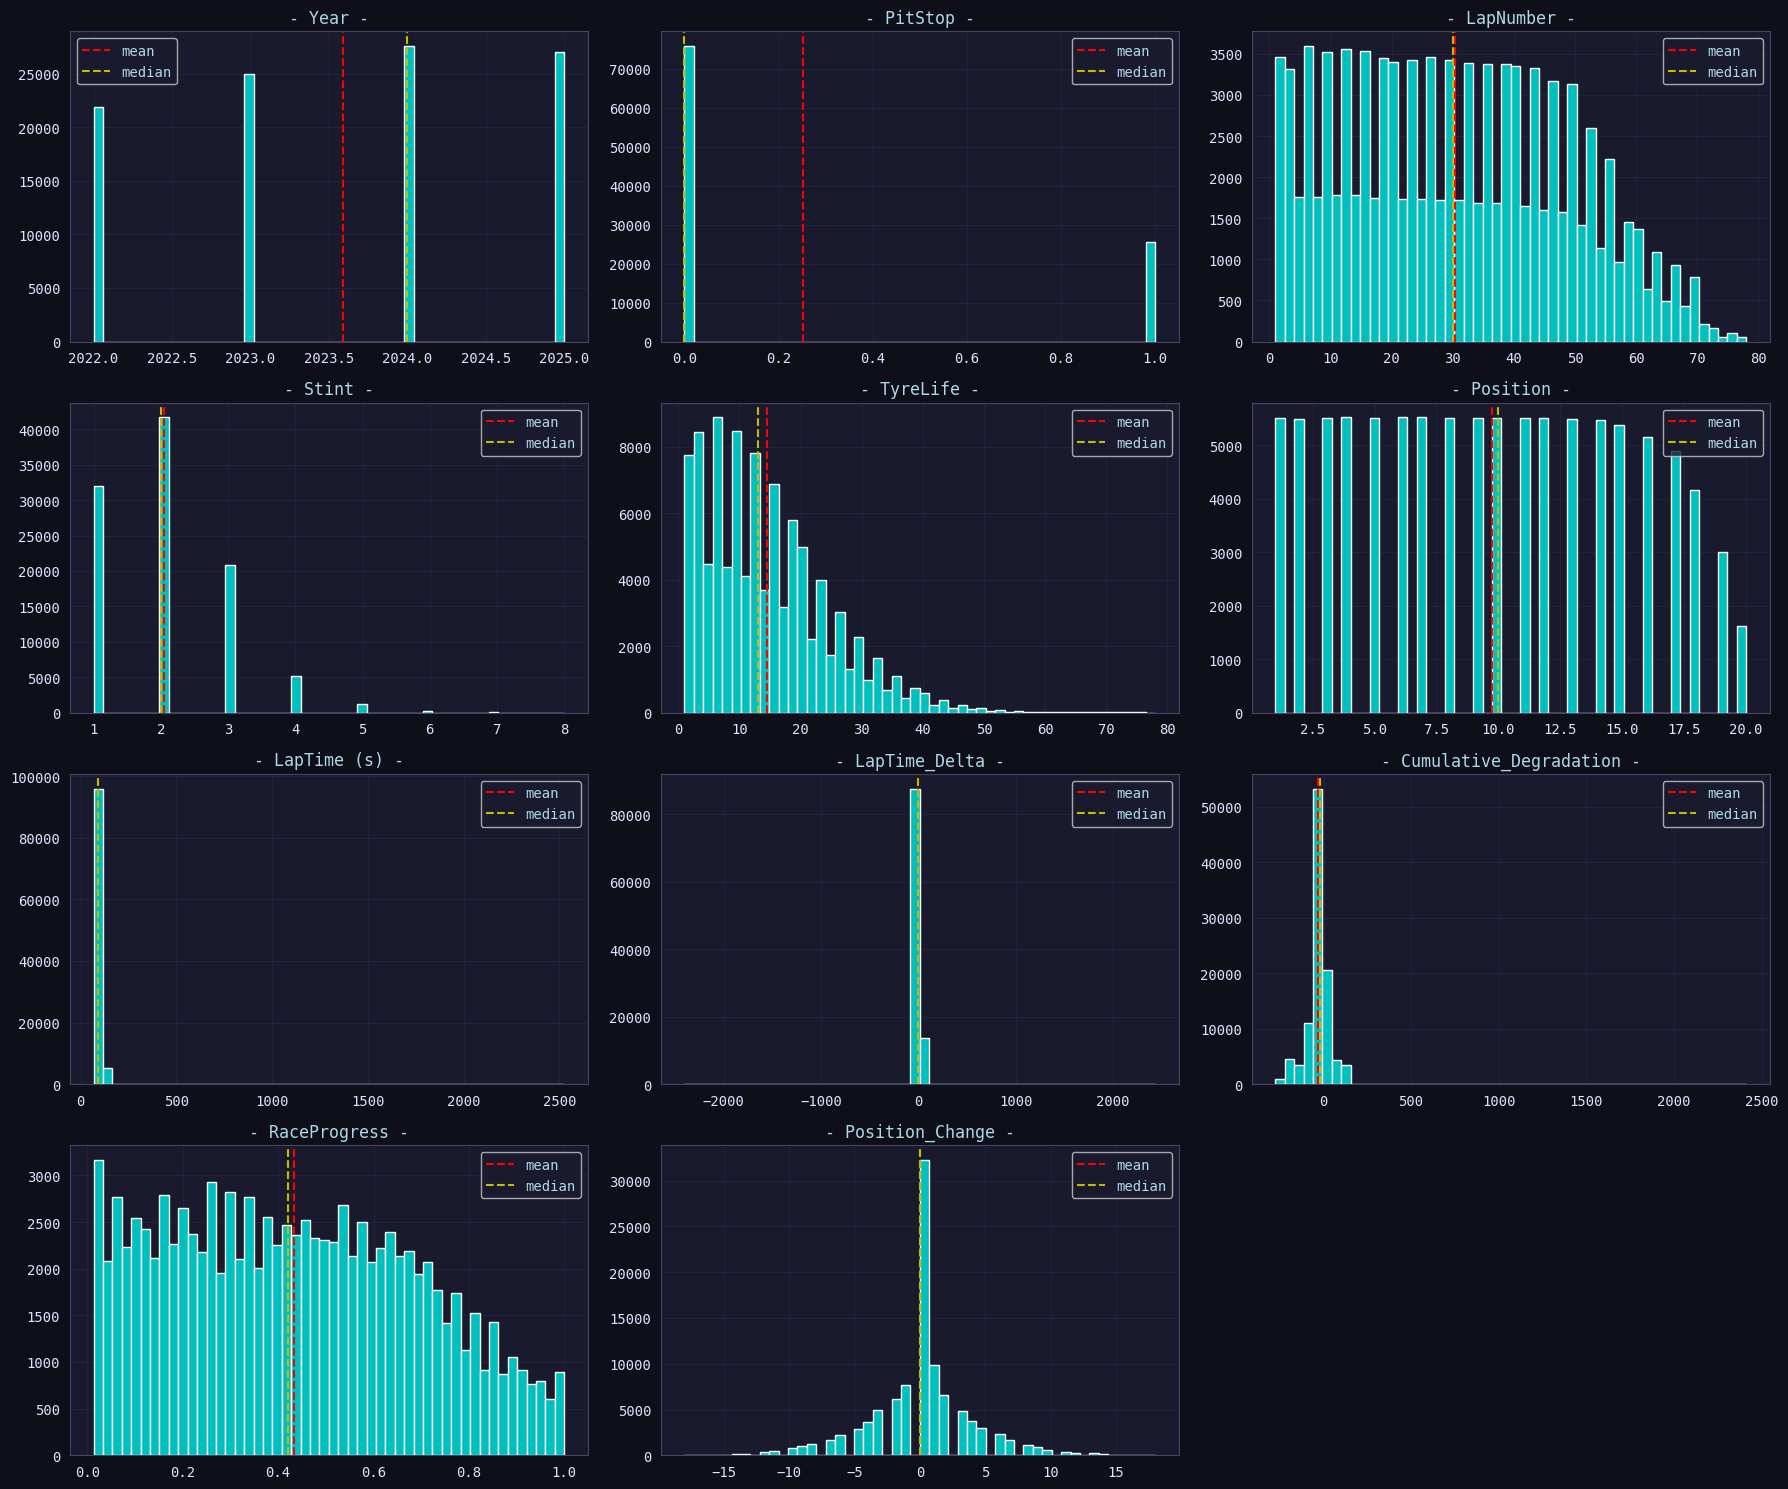

In [7]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [8]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {} 
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Driver,Compound,Race
Train,4,2,78,8,78,20,37719,57532,142701,1898,37,887,5,26
Original,4,2,78,8,78,20,40779,54084,81360,1437,37,31,5,28
Test,4,2,77,8,77,20,30286,40673,86823,1556,37,801,5,26


In [9]:
n_unique = train[BASE].nunique().sort_values()
n_unique

PitStop                        2
Year                           4
Compound                       5
Stint                          8
Position                      20
Race                          26
Position_Change               37
LapNumber                     78
TyreLife                      78
Driver                       887
RaceProgress                1898
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
dtype: int64

In [10]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

print('- Helper Functions Ready -')

- Helper Functions Ready -


## FEATURE ENGINEERING

In [11]:
## -- Rounding | Digit Extractions --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [12]:
_extract_cols = ['Cumulative_Degradation', 'LapTime (s)'] # , 'LapTime_Delta'

print(f"\nRounding... ", end='')
for col in _extract_cols:
    for r in range(-2, 3):
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')

        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    # print(f"\nDIGITS... ", end='')
    # for d in [-3, -2, -1, 0, 1, 2, 3]:
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nCreating value-based E_BINS... ", end='')
    # for b in [100]:
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nCreating quantile-based Q_BINS... ", end='')
    # for q in [100]:
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


Rounding... Cumulative_Degradation_round_-2, Cumulative_Degradation_round_-1, Cumulative_Degradation_round_0, Cumulative_Degradation_round_1, Cumulative_Degradation_round_2, LapTime (s)_round_-2, LapTime (s)_round_-1, LapTime (s)_round_0, LapTime (s)_round_1, LapTime (s)_round_2, 
✅ Total ROUNDS: 10
✅ Total DIGITS: 0
✅ Total E_BINS: 0
✅ Total Q_BINS: 0


In [13]:
# _extract_cols = ['TyreLife', 'Position_Change', 'LapNumber', 'Year']

# for col in _extract_cols:
#     # print(f"\nRounding... ", end='')
#     # for r in [-2, -1, 0, 1, 2]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDigits... ", end='')
#     for d in [-1, 0]:
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [5]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [14]:
# _extract_cols = ['RaceProgress']

# for col in _extract_cols:
#     # print(f"\nRounding... ", end='')
#     # for r in [-2, -1, 0, 1, 2]:
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)

#     print(f"\nDigits... ", end='')
#     for d in range(1, 7):
#         d_n = f'{col}_digit_{d}'
#         print(d_n+', ', end='')
#         train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#         test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#         orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#         ## -- Drop constant features --
#         if train[d_n].nunique() < digit_thresh:
#             DROP_COLS.append(d_n)
#         else:
#             DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [5]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [15]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [16]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Cumulative_Degradation_round_-2      7
Cumulative_Degradation_round_-1     51
Cumulative_Degradation_round_0     454
Cumulative_Degradation_round_1     447
Cumulative_Degradation_round_2     445
LapTime (s)_round_-2                 5
LapTime (s)_round_-1                25
LapTime (s)_round_0                137
LapTime (s)_round_1                134
LapTime (s)_round_2                132
dtype: int64

In [17]:
## -- Flag 'Year' == 2023 --
for df in [train, test, orig]:
    df['is_2023'] = (df['Year'] == 2023).astype('int8')

print('Flag Year:', 'is_2023')

Flag Year: is_2023


In [18]:
# def add_frequency_condition(df1, cols, thresh=5): 
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [19]:
INTER = []
top_cols = ['Year', 'Compound', 'Stint', 'Race', 'PitStop'] # 
low_cols = ['Position', 'Position_Change', 'LapNumber', 'TyreLife']

for c1, c2 in tqdm(list(itertools.combinations(top_cols, 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")

Pairwise:   0%|          | 0/10 [00:00<?, ?it/s]

Total Interaction Features: 10


In [20]:
## -- Arithmetic interactions --
for df in [train, test, orig]:
    df['_LapNumber_div_RaceProgress'] = (df['LapNumber'] / (df['RaceProgress'] + 1e-6)).astype('float32')
    df['_TyreLife_div_LapNumber'] = (df['TyreLife'] / df['LapNumber'].clip(lower=1)).astype('float32')
    df['_LapTime_*_Cum_Degrad'] = (df['LapTime (s)'] * df['Cumulative_Degradation']).astype('float32')
    df['_LapTime_*_Cum_Degrad_abs'] = (df['LapTime (s)'] * df['Cumulative_Degradation'].abs()).astype('float32')
    df['_LapTime_div_Cum_Degrad_abs'] = (df['LapTime (s)'] / (df['Cumulative_Degradation'].abs() + 1e-6)).astype('float32')

arithmetic = [
    '_LapNumber_div_RaceProgress',
    '_TyreLife_div_LapNumber',
    '_LapTime_*_Cum_Degrad',
    '_LapTime_*_Cum_Degrad_abs',
    '_LapTime_div_Cum_Degrad_abs',
]

print(f"Total Arithmetic interactions: {len(arithmetic)}")

train[arithmetic].head()

Total Arithmetic interactions: 5


,_LapNumber_div_RaceProgress,_TyreLife_div_LapNumber,_LapTime_*_Cum_Degrad,_LapTime_*_Cum_Degrad_abs,_LapTime_div_Cum_Degrad_abs
0,69.999901,0.780000,1649.802368,1649.802368,3.734288
1,77.999771,0.259259,-16761.730469,16761.730469,0.336437
2,71.999908,0.372881,-7132.029785,7132.029785,0.705717
3,25.999662,1.000000,-691.099976,691.099976,12.883805
4,71.999802,0.230769,-1525.286987,1525.286987,7.629817


In [21]:
## -- Frequency encoding --
freq_cols = []

print(f"\nCreating frequencies... ", end='')
for col in CATS + ['LapNumber', 'RaceProgress']: # 'Position_Change'
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    n = f'{col}_freq'
    print(n+', ', end='')
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype('float32')
    freq_cols.append(n)

print(f"\n✓ Total frequency features: {len(freq_cols)}")


Creating frequencies... Driver_freq, Compound_freq, Race_freq, LapNumber_freq, RaceProgress_freq, 
✓ Total frequency features: 5


In [22]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [23]:
train.head(3)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,Cumulative_Degradation_round_-2,Cumulative_Degradation_round_-1,Cumulative_Degradation_round_0,Cumulative_Degradation_round_1,Cumulative_Degradation_round_2,LapTime (s)_round_-2,LapTime (s)_round_-1,LapTime (s)_round_0,LapTime (s)_round_1,LapTime (s)_round_2,is_2023,Bi_Year-|-Compound,Bi_Year-|-Stint,Bi_Year-|-Race,Bi_Year-|-PitStop,Bi_Compound-|-Stint,Bi_Compound-|-Race,Bi_Compound-|-PitStop,Bi_Stint-|-Race,Bi_Stint-|-PitStop,Bi_Race-|-PitStop,_LapNumber_div_RaceProgress,_TyreLife_div_LapNumber,_LapTime_*_Cum_Degrad,_LapTime_*_Cum_Degrad_abs,_LapTime_div_Cum_Degrad_abs,Driver_freq,Compound_freq,Race_freq,LapNumber_freq,RaceProgress_freq
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1,0,20,21,21,21,100,80,78,78,78,0,2022_HARD,2022_2,2022_Canadian Grand Prix,2022_0,HARD_2,HARD_Canadian Grand Prix,HARD_0,2_Canadian Grand Prix,2_0,Canadian Grand Prix_0,69.999901,0.780000,1649.802368,1649.802368,3.734288,0.002034,0.395496,0.048945,0.011480,0.000915
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0,-200,-220,-223,-223,-223,100,80,75,75,75,0,2025_HARD,2025_2,2025_Dutch Grand Prix,2025_1,HARD_2,HARD_Dutch Grand Prix,HARD_1,2_Dutch Grand Prix,2_1,Dutch Grand Prix_1,77.999771,0.259259,-16761.730469,16761.730469,0.336437,0.002207,0.395496,0.055289,0.012781,0.002768
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1,-100,-100,-101,-100,-100,100,70,71,70,70,0,2022_HARD,2022_3,2022_Austrian Grand Prix,2022_0,HARD_3,HARD_Austrian Grand Prix,HARD_0,3_Austrian Grand Prix,3_0,Austrian Grand Prix_0,71.999908,0.372881,-7132.029785,7132.029785,0.705717,0.002893,0.395496,0.047861,0.003255,0.001118


In [24]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [25]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [26]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [27]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE+DIGITS,
#     target=TARGET,
#     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#     # fill_nan=True,
# )

# print(F"ORIGINAL FEATURES MERGED: {len(ORIG_COLS)}")

In [28]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []
# nums_cats = [c for c in n_unique[n_unique < 1000].index if c not in CATS] #+ orig_cols

# for c in nums_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize --
#     combine  = pd.concat([train[n], test[n]])
#     __ = combine.factorize()[0]
#     train[n] = __[:len(train)].astype('int32')
#     test[n]  = __[len(train):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')
# CATS_2

In [29]:
## -- Factorize using combined data --
for c in CATS:
    combined = pd.concat([train[c], test[c], orig[c]])
    combined = combined.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combined[:len(train)]
    test[c]  = combined[len(train):len(train)+len(test)]
    orig[c]  = combined[-len(orig):]

print('Label encoding complete!')

Label encoding complete!


In [30]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train[FEATURES].head(3)

Total Features: 45


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Cumulative_Degradation_round_-2,Cumulative_Degradation_round_-1,Cumulative_Degradation_round_0,Cumulative_Degradation_round_1,Cumulative_Degradation_round_2,LapTime (s)_round_-2,LapTime (s)_round_-1,LapTime (s)_round_0,LapTime (s)_round_1,LapTime (s)_round_2,is_2023,Bi_Year-|-Compound,Bi_Year-|-Stint,Bi_Year-|-Race,Bi_Year-|-PitStop,Bi_Compound-|-Stint,Bi_Compound-|-Race,Bi_Compound-|-PitStop,Bi_Stint-|-Race,Bi_Stint-|-PitStop,Bi_Race-|-PitStop,_LapNumber_div_RaceProgress,_TyreLife_div_LapNumber,_LapTime_*_Cum_Degrad,_LapTime_*_Cum_Degrad_abs,_LapTime_div_Cum_Degrad_abs,Driver_freq,Compound_freq,Race_freq,LapNumber_freq,RaceProgress_freq
0,0,0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,0,20,21,21,21,100,80,78,78,78,0,2022_HARD,2022_2,2022_Canadian Grand Prix,2022_0,HARD_2,HARD_Canadian Grand Prix,HARD_0,2_Canadian Grand Prix,2_0,Canadian Grand Prix_0,69.999901,0.780000,1649.802368,1649.802368,3.734288,0.002034,0.395496,0.048945,0.011480,0.000915
1,1,0,1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,-200,-220,-223,-223,-223,100,80,75,75,75,0,2025_HARD,2025_2,2025_Dutch Grand Prix,2025_1,HARD_2,HARD_Dutch Grand Prix,HARD_1,2_Dutch Grand Prix,2_1,Dutch Grand Prix_1,77.999771,0.259259,-16761.730469,16761.730469,0.336437,0.002207,0.395496,0.055289,0.012781,0.002768
2,2,0,2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,-100,-100,-101,-100,-100,100,70,71,70,70,0,2022_HARD,2022_3,2022_Austrian Grand Prix,2022_0,HARD_3,HARD_Austrian Grand Prix,HARD_0,3_Austrian Grand Prix,3_0,Austrian Grand Prix_0,71.999908,0.372881,-7132.029785,7132.029785,0.705717,0.002893,0.395496,0.047861,0.003255,0.001118


# ML TRAINING

In [31]:
try:
    import catboost as cgb
except:
    %pip install -q catboost
    import catboost as cgb

# try:
#     from venn_abers import VennAbersCalibrator
# except:
#     %pip install -q venn-abers
#     from venn_abers import VennAbersCalibrator

# try:
#     from cir_model import CenteredIsotonicRegression
# except:
#     %pip install -q cir-model
#     from cir_model import CenteredIsotonicRegression

print('CatBoost version:', cgb.__version__)

CatBoost version: 1.2.10


In [32]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats):
    print(f"\n========== Starting Cross-Validation for {model_name} ==========")
    start = time()
    
    X = train_df[features]
    y = train_df[target]

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} - ", end='')

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]

        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_valid, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_valid,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # cme_features = ROUNDS
        # cme_cols = []

        # ce_cols = ['Driver', 'Position']
        # print(f" • Cat_Mean Encoding {len(ce_cols)} features...")
        # cm_enc  = CategoryMeanTransformer(cat_cols=ce_cols)
        # X_train = cm_enc.fit_transform(X_train, y_train)
        # X_valid = cm_enc.transform(X_valid)
        # X_test  = cm_enc.transform(X_test)

        # TE = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        # X_train = TE.fit_transform(X_train, y_train)
        # X_valid = TE.transform(X_valid)
        # X_test  = TE.transform(X_test)

        all_categorical = cats
        combined = pd.concat([X_train, X_valid, X_test])
        
        for c in all_categorical:
            combined[c] = combined[c].astype('str')

        X_train = combined.iloc[:len(X_train)]
        X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        X_test  = combined.iloc[len(X_train)+len(X_valid):]

        print(f"Train shape: {X_train.shape} *****")

        dtrain = cgb.Pool(data=X_train, label=y_train, cat_features=all_categorical)
        dval   = cgb.Pool(data=X_valid, label=y_valid, cat_features=all_categorical)
        dtest  = cgb.Pool(data=X_test, cat_features=all_categorical)

        model = cgb.train(
            dtrain=dtrain,
            params=params,
            num_boost_round=50_000,
            eval_set=dval,
            early_stopping_rounds=200,
            verbose=1000,
        )

        # Predict on validation and test sets
        oof_preds[val_idx] = model.predict(dval, prediction_type='Probability')[:, 1]
        test_preds += model.predict(dtest, prediction_type='Probability')[:, 1]

        ## -- Calculate fold score --
        fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f'{CFG.YELLOW} • Fold {idx+1} Score: {fold_score:.5f}{CFG.RESET}')

        ## -- Clean up memory --
        del X_train, y_train, y_valid, X_test, dtrain, dval, dtest, combined
        gc.collect()

    ## -- Average the test predictions --
    test_preds /= kf.n_splits

    ## -- CV results --
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f" • Fold {i+1} Score: {score:.5f}")

    ## -- Calculate out-of-fold Score --
    final_score = np.round(roc_auc_score(y, oof_preds), 5)

    print("-------------------------------------------------|")
    print(f"Overall Score: {final_score}")
    print(f"Average Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': final_score,
        'model': model,
        'val_data': X_valid,
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [33]:
version_name = 'cat_v0_'
all_model_predictions = {}

MULTI_SEEDS = [CFG.SEED] #, 777, 1234, 24611, 0]
ALL_CATS = CATS + ['Year', 'Stint'] + ['PitStop', 'is_2023'] + ROUNDS + INTER

N_SPLITS = 5
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CFG.SEED)

kf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [34]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """

# if all_model_predictions:
#     all_model_predictions.clear()

# M_NAME = '_'
# COMPILER = []

# OUT_LOOP = [4, 5]
# INN_LOOP = [0]
# p_name   = ['l2', '-']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # 'boosting_type': value,
#             # ---------------------------------
#             'grow_policy': 'SymmetricTree',
#             # ---------------------------------
#             'bootstrap_type': 'Bayesian',
#             'bagging_temperature': 0.5,
#             # 'random_strength': 1.0,
#             # ---------------------------------
#             'loss_function': 'Logloss',
#             'eval_metric': 'AUC',
#             'learning_rate': 0.1,
#             'depth': 6,
#             'l2_leaf_reg': outer,
#             'thread_count': os.cpu_count(),
#             'allow_writing_files': False,
#             'random_state': CFG.SEED,
#             'verbose': 0,
#             'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
#         }

#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=ALL_CATS,
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n===== Results ready for {len(COMPILER)} models =====")

In [35]:
# CatBoostTE (INTER + ROUNDS) =====================
# Cross-Validation Results for _l2=4__-=0
# ==================================================
#  • Fold 1 Score: 0.95261
#  • Fold 2 Score: 0.95069
#  • Fold 3 Score: 0.95187
#  • Fold 4 Score: 0.95086
#  • Fold 5 Score: 0.95228
# -------------------------------------------------|
# Overall Score: 0.95165
# Average Score: 0.95166 ± 0.00076
# -------------------------------------------------|
# 16.64 mins

In [36]:
# ## -- Get Scores --
# all_model_scores = {}
# all_scores = []

# for k, v in all_model_predictions.items():
#     for x, y in v.items():
#         if x == 'score':
#             all_model_scores[k] = y
#             all_scores.append(float(y))

# # fig, ax = plt.subplots(figsize=(15, 5))
# # ax.plot(all_model_scores.keys(), all_model_scores.values(), marker='o')

# plt.figure(figsize=(16, 5))
# ax = sns.lineplot(all_model_scores, marker='o')

# ax.fill_between(range(len(all_model_scores)), all_model_scores.values(), alpha=0.1)
# ax.set_title('Models scores', fontweight='semibold')
# ax.tick_params('x', rotation=30)
# ax.set_ylim(0.94, 0.955)

# for i, s in enumerate(all_model_scores.values()):
#     ax.text(float(i), s+1e-3, s, ha='center', va='baseline')

# plt.tight_layout()
# plt.show()

In [37]:
LR = 0.03
L2_REG = 4.0

LR, L2_REG

(0.03, 4.0)

In [38]:
## ===== BAYES =====

PARAMS = {
    'boosting_type': 'Plain',
    # ---------------------------------
    'grow_policy': 'SymmetricTree',
    # ---------------------------------
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0.5,
    # 'random_strength': 0.8,
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'depth': 6,
    'l2_leaf_reg': L2_REG,
    'thread_count': os.cpu_count(),
    'allow_writing_files': False,
    'random_state': CFG.SEED,
    'verbose': 0,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}
n = f"{version_name}bayes_"

# for b_seed in MULTI_SEEDS:
#     PARAMS['random_state'] = b_seed
#     n = f"{version_name}bayes_" + str(b_seed)
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
)

# ## ==================================================== 

# M_NAME = f"{version_name}MVS_"

# PARAMS = {
#     # 'boosting_type': 'Plain',
#     # ---------------------------------
#     'grow_policy': 'Depthwise',
#     # ---------------------------------
#     'bootstrap_type': 'MVS',
#     # 'min_data_in_leaf': 2,
#     'subsample': 0.8, # auto 0.8 for 'MVS'
#     # ---------------------------------
#     'loss_function': 'Logloss',
#     'eval_metric': 'AUC',
#     'learning_rate': LR,
#     # 'depth': 6,
#     'l2_leaf_reg': L2_REG,
#     'random_state': SEED,
#     'verbose': 0,
#     'allow_writing_files': False,
#     'thread_count': os.cpu_count(),
#     'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
# }

# n = M_NAME + str(LR).split('.')[1] + '_' +  str(SEED)

# all_model_predictions[n] = Trainer_CV(
#     model_name=n,
#     params=PARAMS,
#     train_df=train,
#     test_df=test,
#     features=FEATURES,
#     target=TARGET,
#     kf=kf,
#     cats=CATS
# )



========== Starting Cross-Validation for cat_v0_bayes_ ==========

***** FOLD 1/5 - Train shape: (351312, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9197302	best: 0.9197302 (0)	total: 340ms	remaining: 4h 43m 26s
1000:	test: 0.9492777	best: 0.9492777 (1000)	total: 1m	remaining: 49m 9s
2000:	test: 0.9510438	best: 0.9510438 (2000)	total: 2m	remaining: 48m 17s
3000:	test: 0.9517780	best: 0.9517780 (2999)	total: 3m 1s	remaining: 47m 29s
4000:	test: 0.9521909	best: 0.9521921 (3996)	total: 4m 3s	remaining: 46m 43s
5000:	test: 0.9524884	best: 0.9524884 (5000)	total: 5m 6s	remaining: 46m
6000:	test: 0.9527052	best: 0.9527059 (5984)	total: 6m 9s	remaining: 45m 11s
7000:	test: 0.9528549	best: 0.9528571 (6958)	total: 7m 13s	remaining: 44m 25s
8000:	test: 0.9530010	best: 0.9530014 (7998)	total: 8m 18s	remaining: 43m 37s
9000:	test: 0.9530753	best: 0.9530765 (8994)	total: 9m 23s	remaining: 42m 46s
10000:	test: 0.9531448	best: 0.9531463 (9912)	total: 10m 29s	remaining: 41m 56s
11000:	test: 0.9532032	best: 0.9532053 (10982)	total: 11m 35s	remaining: 41m 7s
bestTest = 0.9532331824
bestIteration = 11230
Shrink model to first 11231 iterati

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9172812	best: 0.9172812 (0)	total: 97.5ms	remaining: 1h 21m 16s
1000:	test: 0.9469396	best: 0.9469396 (1000)	total: 1m 1s	remaining: 49m 53s
2000:	test: 0.9488137	best: 0.9488137 (2000)	total: 2m 1s	remaining: 48m 38s
3000:	test: 0.9495661	best: 0.9495661 (3000)	total: 3m 2s	remaining: 47m 40s
4000:	test: 0.9500597	best: 0.9500597 (4000)	total: 4m 4s	remaining: 46m 45s
5000:	test: 0.9503763	best: 0.9503763 (4997)	total: 5m 6s	remaining: 45m 58s
6000:	test: 0.9505953	best: 0.9505976 (5987)	total: 6m 9s	remaining: 45m 10s
7000:	test: 0.9507686	best: 0.9507696 (6989)	total: 7m 13s	remaining: 44m 24s
8000:	test: 0.9508904	best: 0.9508904 (7999)	total: 8m 18s	remaining: 43m 37s
9000:	test: 0.9509778	best: 0.9509797 (8963)	total: 9m 24s	remaining: 42m 49s
10000:	test: 0.9510639	best: 0.9510647 (9997)	total: 10m 30s	remaining: 41m 59s
11000:	test: 0.9511428	best: 0.9511430 (10993)	total: 11m 36s	remaining: 41m 10s
bestTest = 0.9511649013
bestIteration = 11313
Shrink model to first 

...

0:	test: 0.9186101	best: 0.9186101 (0)	total: 101ms	remaining: 1h 24m
1000:	test: 0.9487746	best: 0.9487746 (1000)	total: 1m	remaining: 49m 37s
2000:	test: 0.9503853	best: 0.9503856 (1999)	total: 2m 1s	remaining: 48m 46s
3000:	test: 0.9510904	best: 0.9510905 (2999)	total: 3m 3s	remaining: 47m 52s
4000:	test: 0.9514933	best: 0.9514945 (3997)	total: 4m 5s	remaining: 46m 56s
5000:	test: 0.9517587	best: 0.9517593 (4991)	total: 5m 6s	remaining: 46m 2s
6000:	test: 0.9519624	best: 0.9519630 (5997)	total: 6m 9s	remaining: 45m 10s
7000:	test: 0.9520729	best: 0.9520729 (6996)	total: 7m 13s	remaining: 44m 21s
8000:	test: 0.9521551	best: 0.9521565 (7971)	total: 8m 18s	remaining: 43m 37s
9000:	test: 0.9522198	best: 0.9522226 (8986)	total: 9m 24s	remaining: 42m 49s
bestTest = 0.9522559047
bestIteration = 9396
Shrink model to first 9397 iterations.
 • Fold 3 Score: 0.95226

***** FOLD 4/5 - Train shape: (351312, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9189035	best: 0.9189035 (0)	total: 100ms	remaining: 1h 23m 30s
1000:	test: 0.9471341	best: 0.9471341 (1000)	total: 1m	remaining: 49m 41s
2000:	test: 0.9490999	best: 0.9490999 (2000)	total: 2m 1s	remaining: 48m 33s
3000:	test: 0.9498891	best: 0.9498891 (3000)	total: 3m 2s	remaining: 47m 42s
4000:	test: 0.9503442	best: 0.9503442 (4000)	total: 4m 4s	remaining: 46m 51s
5000:	test: 0.9506524	best: 0.9506530 (4995)	total: 5m 7s	remaining: 46m 7s
6000:	test: 0.9508719	best: 0.9508719 (6000)	total: 6m 11s	remaining: 45m 20s
7000:	test: 0.9510363	best: 0.9510379 (6998)	total: 7m 15s	remaining: 44m 33s
8000:	test: 0.9511373	best: 0.9511388 (7971)	total: 8m 19s	remaining: 43m 44s
9000:	test: 0.9512498	best: 0.9512499 (8999)	total: 9m 25s	remaining: 42m 57s
10000:	test: 0.9513152	best: 0.9513152 (10000)	total: 10m 32s	remaining: 42m 10s
11000:	test: 0.9514074	best: 0.9514135 (10903)	total: 11m 40s	remaining: 41m 23s
bestTest = 0.9514134526
bestIteration = 10903
Shrink model to first 109

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9184106	best: 0.9184106 (0)	total: 93.8ms	remaining: 1h 18m 8s
1000:	test: 0.9485017	best: 0.9485017 (1000)	total: 1m 1s	remaining: 49m 46s
2000:	test: 0.9504250	best: 0.9504250 (2000)	total: 2m 1s	remaining: 48m 38s
3000:	test: 0.9512390	best: 0.9512396 (2999)	total: 3m 3s	remaining: 47m 47s
4000:	test: 0.9517241	best: 0.9517241 (4000)	total: 4m 5s	remaining: 46m 59s
5000:	test: 0.9520274	best: 0.9520277 (4999)	total: 5m 8s	remaining: 46m 14s
6000:	test: 0.9522734	best: 0.9522738 (5999)	total: 6m 11s	remaining: 45m 23s
7000:	test: 0.9524417	best: 0.9524428 (6992)	total: 7m 15s	remaining: 44m 35s
8000:	test: 0.9525786	best: 0.9525796 (7988)	total: 8m 20s	remaining: 43m 46s
9000:	test: 0.9526755	best: 0.9526759 (8997)	total: 9m 25s	remaining: 42m 56s
10000:	test: 0.9527513	best: 0.9527521 (9997)	total: 10m 32s	remaining: 42m 8s
11000:	test: 0.9528362	best: 0.9528386 (10990)	total: 11m 39s	remaining: 41m 21s
bestTest = 0.9528421164
bestIteration = 11045
Shrink model to first 1

In [39]:
## ===== BERNOULLI =====

PARAMS = {
    'boosting_type': 'Plain',
    # ---------------------------------
    'grow_policy': 'Depthwise',
    # ---------------------------------
    'bootstrap_type': 'Bernoulli',
    # 'subsample': 0.8, # auto 0.66 for 'Bernoulli'
    # 'colsample_bylevel': 0.7,
    # 'min_data_in_leaf': 20,
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'depth': 6,
    'l2_leaf_reg': L2_REG,
    'thread_count': os.cpu_count(),
    'allow_writing_files': False,
    'random_state': CFG.SEED,
    'verbose': 0,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

for be_seed in MULTI_SEEDS:
    PARAMS['random_state'] = be_seed
    n = f"{version_name}bern_" + str(be_seed)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=ALL_CATS,
    )


========== Starting Cross-Validation for cat_v0_bern_42 ==========

***** FOLD 1/5 - Train shape: (351312, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9303007	best: 0.9303007 (0)	total: 190ms	remaining: 2h 38m 37s
1000:	test: 0.9499829	best: 0.9499829 (1000)	total: 25s	remaining: 20m 21s
2000:	test: 0.9514684	best: 0.9514684 (2000)	total: 49.2s	remaining: 19m 40s
3000:	test: 0.9521199	best: 0.9521199 (3000)	total: 1m 14s	remaining: 19m 22s
4000:	test: 0.9524336	best: 0.9524351 (3997)	total: 1m 39s	remaining: 18m 58s
5000:	test: 0.9525622	best: 0.9525650 (4992)	total: 2m 4s	remaining: 18m 38s
bestTest = 0.9526128173
bestIteration = 5591
Shrink model to first 5592 iterations.
 • Fold 1 Score: 0.95261

***** FOLD 2/5 - Train shape: (351312, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9280085	best: 0.9280085 (0)	total: 40.1ms	remaining: 33m 23s
1000:	test: 0.9479795	best: 0.9479795 (1000)	total: 25s	remaining: 20m 24s
2000:	test: 0.9494017	best: 0.9494017 (2000)	total: 47.7s	remaining: 19m 3s
3000:	test: 0.9500079	best: 0.9500079 (3000)	total: 1m 12s	remaining: 18m 50s
4000:	test: 0.9503080	best: 0.9503115 (3985)	total: 1m 35s	remaining: 18m 15s
5000:	test: 0.9504281	best: 0.9504284 (4993)	total: 1m 58s	remaining: 17m 49s
bestTest = 0.9504381418
bestIteration = 5050
Shrink model to first 5051 iterations.
 • Fold 2 Score: 0.95044

***** FOLD 3/5 - Train shape: (351312, 45) *****


...

0:	test: 0.9306129	best: 0.9306129 (0)	total: 40.6ms	remaining: 33m 47s
1000:	test: 0.9493729	best: 0.9493729 (1000)	total: 25.7s	remaining: 21m
2000:	test: 0.9507959	best: 0.9507959 (2000)	total: 50.1s	remaining: 20m 1s
3000:	test: 0.9513933	best: 0.9513933 (2992)	total: 1m 15s	remaining: 19m 35s
4000:	test: 0.9516236	best: 0.9516240 (3999)	total: 1m 39s	remaining: 19m 5s
5000:	test: 0.9517332	best: 0.9517364 (4997)	total: 2m 2s	remaining: 18m 25s
bestTest = 0.951759994
bestIteration = 5286
Shrink model to first 5287 iterations.
 • Fold 3 Score: 0.95176

***** FOLD 4/5 - Train shape: (351312, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9303808	best: 0.9303808 (0)	total: 40.8ms	remaining: 33m 59s
1000:	test: 0.9483201	best: 0.9483201 (1000)	total: 24.4s	remaining: 19m 53s
2000:	test: 0.9498392	best: 0.9498395 (1999)	total: 48.9s	remaining: 19m 33s
3000:	test: 0.9504218	best: 0.9504243 (2997)	total: 1m 14s	remaining: 19m 22s
4000:	test: 0.9507201	best: 0.9507247 (3933)	total: 1m 38s	remaining: 18m 51s
5000:	test: 0.9508354	best: 0.9508467 (4952)	total: 2m 2s	remaining: 18m 25s
bestTest = 0.9508466721
bestIteration = 4952
Shrink model to first 4953 iterations.
 • Fold 4 Score: 0.95085

***** FOLD 5/5 - Train shape: (351312, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9309002	best: 0.9309002 (0)	total: 39.9ms	remaining: 33m 14s
1000:	test: 0.9495509	best: 0.9495509 (1000)	total: 25.4s	remaining: 20m 43s
2000:	test: 0.9511603	best: 0.9511603 (2000)	total: 51.2s	remaining: 20m 28s
3000:	test: 0.9518335	best: 0.9518337 (2999)	total: 1m 17s	remaining: 20m 8s
4000:	test: 0.9521950	best: 0.9521955 (3996)	total: 1m 40s	remaining: 19m 19s
5000:	test: 0.9523576	best: 0.9523649 (4899)	total: 2m 5s	remaining: 18m 49s
bestTest = 0.9524243474
bestIteration = 5689
Shrink model to first 5690 iterations.
 • Fold 5 Score: 0.95242

Cross-Validation Results for cat_v0_bern_42
 • Fold 1 Score: 0.95261
 • Fold 2 Score: 0.95044
 • Fold 3 Score: 0.95176
 • Fold 4 Score: 0.95085
 • Fold 5 Score: 0.95242
-------------------------------------------------|
Overall Score: 0.95161
Average Score: 0.95162 ± 0.00085
-------------------------------------------------|
13.53 mins



In [40]:
## ====== LOSS =====

PARAMS = {
    'boosting_type': 'Plain',
    # ---------------------------------
    'grow_policy': 'Lossguide',
    # ---------------------------------
    'max_leaves': 64,
    # 'min_data_in_leaf': 20,
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'depth': 6,
    'l2_leaf_reg': L2_REG,
    'thread_count': os.cpu_count(),
    'allow_writing_files': False,
    'random_state': CFG.SEED,
    'verbose': 0,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

for l_seed in MULTI_SEEDS:
    PARAMS['random_state'] = l_seed
    n = f"{version_name}loss_" + str(l_seed)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=ALL_CATS,
    )


========== Starting Cross-Validation for cat_v0_loss_42 ==========

***** FOLD 1/5 - Train shape: (351312, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9295377	best: 0.9295377 (0)	total: 65.6ms	remaining: 54m 38s
1000:	test: 0.9512389	best: 0.9512389 (1000)	total: 51.8s	remaining: 42m 17s
2000:	test: 0.9524716	best: 0.9524716 (2000)	total: 1m 44s	remaining: 41m 53s
3000:	test: 0.9528922	best: 0.9528929 (2999)	total: 2m 36s	remaining: 40m 51s
4000:	test: 0.9530947	best: 0.9530948 (3997)	total: 3m 28s	remaining: 39m 51s
5000:	test: 0.9531493	best: 0.9531561 (4845)	total: 4m 19s	remaining: 38m 57s
bestTest = 0.953156054
bestIteration = 4845
Shrink model to first 4846 iterations.
 • Fold 1 Score: 0.95316

***** FOLD 2/5 - Train shape: (351312, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9278680	best: 0.9278680 (0)	total: 63.8ms	remaining: 53m 9s
1000:	test: 0.9492037	best: 0.9492038 (999)	total: 53.1s	remaining: 43m 20s
2000:	test: 0.9504107	best: 0.9504116 (1998)	total: 1m 46s	remaining: 42m 46s
3000:	test: 0.9507716	best: 0.9507734 (2980)	total: 2m 38s	remaining: 41m 14s
4000:	test: 0.9508732	best: 0.9508775 (3802)	total: 3m 30s	remaining: 40m 23s
bestTest = 0.9508774877
bestIteration = 3802
Shrink model to first 3803 iterations.
 • Fold 2 Score: 0.95088

***** FOLD 3/5 - Train shape: (351312, 45) *****


...

0:	test: 0.9299712	best: 0.9299712 (0)	total: 62.5ms	remaining: 52m 5s
1000:	test: 0.9506418	best: 0.9506437 (998)	total: 47.3s	remaining: 38m 35s
2000:	test: 0.9517372	best: 0.9517388 (1998)	total: 1m 41s	remaining: 40m 42s
3000:	test: 0.9520238	best: 0.9520292 (2964)	total: 2m 33s	remaining: 40m 5s
4000:	test: 0.9521099	best: 0.9521149 (3957)	total: 3m 26s	remaining: 39m 35s
bestTest = 0.9521741271
bestIteration = 4490
Shrink model to first 4491 iterations.
 • Fold 3 Score: 0.95217

***** FOLD 4/5 - Train shape: (351312, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9288824	best: 0.9288824 (0)	total: 64.2ms	remaining: 53m 30s
1000:	test: 0.9494922	best: 0.9494922 (1000)	total: 53.9s	remaining: 44m
2000:	test: 0.9507367	best: 0.9507372 (1999)	total: 1m 46s	remaining: 42m 46s
3000:	test: 0.9511666	best: 0.9511666 (3000)	total: 2m 37s	remaining: 41m 3s
bestTest = 0.9512541294
bestIteration = 3502
Shrink model to first 3503 iterations.
 • Fold 4 Score: 0.95125

***** FOLD 5/5 - Train shape: (351312, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9296612	best: 0.9296612 (0)	total: 63.6ms	remaining: 53m 1s
1000:	test: 0.9508719	best: 0.9508719 (1000)	total: 49.8s	remaining: 40m 35s
2000:	test: 0.9522060	best: 0.9522060 (1999)	total: 1m 44s	remaining: 41m 45s
3000:	test: 0.9526773	best: 0.9526773 (2999)	total: 2m 37s	remaining: 41m 3s
4000:	test: 0.9527892	best: 0.9527923 (3984)	total: 3m 31s	remaining: 40m 34s
bestTest = 0.9528295398
bestIteration = 4321
Shrink model to first 4322 iterations.
 • Fold 5 Score: 0.95283

Cross-Validation Results for cat_v0_loss_42
 • Fold 1 Score: 0.95316
 • Fold 2 Score: 0.95088
 • Fold 3 Score: 0.95217
 • Fold 4 Score: 0.95125
 • Fold 5 Score: 0.95283
-------------------------------------------------|
Overall Score: 0.95206
Average Score: 0.95206 ± 0.00088
-------------------------------------------------|
21.06 mins



In [41]:
## ===== ORDERED =====

PARAMS = {
    'boosting_type': 'Ordered',
    # ---------------------------------
    'grow_policy': 'SymmetricTree',
    # ---------------------------------
    'bootstrap_type': 'Bayesian',
    'bagging_temperature': 0.5,
    # 'random_sampling': 0.8,
    # ---------------------------------
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'learning_rate': LR,
    # 'depth': 6,
    'l2_leaf_reg': L2_REG,
    'thread_count': os.cpu_count(),
    'allow_writing_files': False,
    'random_state': CFG.SEED,
    'verbose': 0,
    'task_type': 'GPU' if torch.cuda.is_available() else 'CPU',
}

for or_seed in MULTI_SEEDS:
    PARAMS['random_state'] = or_seed
    n = f"{version_name}ord_bayes_" + str(or_seed)
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        train_df=train,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
        cats=ALL_CATS,
    )


========== Starting Cross-Validation for cat_v0_ord_bayes_42 ==========

***** FOLD 1/5 - Train shape: (351312, 45) *****


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9203894	best: 0.9203894 (0)	total: 186ms	remaining: 2h 34m 38s
1000:	test: 0.9489282	best: 0.9489282 (1000)	total: 1m 46s	remaining: 1h 26m 28s
2000:	test: 0.9502922	best: 0.9502923 (1998)	total: 3m 25s	remaining: 1h 22m 14s
3000:	test: 0.9507818	best: 0.9507818 (2995)	total: 5m 2s	remaining: 1h 18m 55s
4000:	test: 0.9511700	best: 0.9511700 (4000)	total: 6m 40s	remaining: 1h 16m 40s
5000:	test: 0.9514074	best: 0.9514074 (4994)	total: 8m 16s	remaining: 1h 14m 31s
6000:	test: 0.9515457	best: 0.9515458 (5980)	total: 9m 52s	remaining: 1h 12m 25s
7000:	test: 0.9517103	best: 0.9517103 (6993)	total: 11m 30s	remaining: 1h 10m 38s
8000:	test: 0.9518164	best: 0.9518164 (7999)	total: 13m 7s	remaining: 1h 8m 54s
9000:	test: 0.9518954	best: 0.9518954 (9000)	total: 14m 46s	remaining: 1h 7m 16s
10000:	test: 0.9519616	best: 0.9519616 (10000)	total: 16m 24s	remaining: 1h 5m 37s
11000:	test: 0.9520186	best: 0.9520187 (10991)	total: 18m 3s	remaining: 1h 4m 1s
12000:	test: 0.9520613	best: 0.952

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9162960	best: 0.9162960 (0)	total: 192ms	remaining: 2h 40m 15s
1000:	test: 0.9471304	best: 0.9471304 (1000)	total: 1m 46s	remaining: 1h 26m 32s
2000:	test: 0.9487085	best: 0.9487085 (1999)	total: 3m 29s	remaining: 1h 23m 50s
3000:	test: 0.9493039	best: 0.9493039 (2999)	total: 5m 11s	remaining: 1h 21m 25s
4000:	test: 0.9496567	best: 0.9496567 (4000)	total: 6m 53s	remaining: 1h 19m 9s
5000:	test: 0.9498774	best: 0.9498777 (4998)	total: 8m 33s	remaining: 1h 16m 56s
6000:	test: 0.9500855	best: 0.9500862 (5996)	total: 10m 13s	remaining: 1h 15m
7000:	test: 0.9502170	best: 0.9502170 (6997)	total: 11m 54s	remaining: 1h 13m 10s
8000:	test: 0.9503260	best: 0.9503261 (7999)	total: 13m 37s	remaining: 1h 11m 28s
9000:	test: 0.9504166	best: 0.9504175 (8988)	total: 15m 20s	remaining: 1h 9m 53s
10000:	test: 0.9505057	best: 0.9505057 (9999)	total: 17m 4s	remaining: 1h 8m 15s
11000:	test: 0.9505559	best: 0.9505562 (10997)	total: 18m 48s	remaining: 1h 6m 39s
12000:	test: 0.9506095	best: 0.9506

...

0:	test: 0.9185434	best: 0.9185434 (0)	total: 196ms	remaining: 2h 43m 13s
1000:	test: 0.9487003	best: 0.9487003 (1000)	total: 1m 46s	remaining: 1h 27m 11s
2000:	test: 0.9501621	best: 0.9501621 (2000)	total: 3m 30s	remaining: 1h 24m 13s
3000:	test: 0.9506844	best: 0.9506844 (3000)	total: 5m 12s	remaining: 1h 21m 31s
4000:	test: 0.9510694	best: 0.9510694 (4000)	total: 6m 55s	remaining: 1h 19m 39s
5000:	test: 0.9513025	best: 0.9513025 (4996)	total: 8m 37s	remaining: 1h 17m 33s
6000:	test: 0.9514532	best: 0.9514537 (5995)	total: 10m 18s	remaining: 1h 15m 35s
7000:	test: 0.9515679	best: 0.9515687 (6984)	total: 12m	remaining: 1h 13m 44s
8000:	test: 0.9516444	best: 0.9516444 (8000)	total: 13m 43s	remaining: 1h 12m 2s
9000:	test: 0.9516843	best: 0.9516843 (9000)	total: 15m 25s	remaining: 1h 10m 16s
10000:	test: 0.9517438	best: 0.9517438 (10000)	total: 17m 9s	remaining: 1h 8m 38s
11000:	test: 0.9517940	best: 0.9517946 (10982)	total: 18m 55s	remaining: 1h 7m 4s
12000:	test: 0.9518147	best: 0.951

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9189035	best: 0.9189035 (0)	total: 192ms	remaining: 2h 39m 51s
1000:	test: 0.9470887	best: 0.9470887 (1000)	total: 1m 45s	remaining: 1h 26m 11s
2000:	test: 0.9486734	best: 0.9486734 (2000)	total: 3m 28s	remaining: 1h 23m 18s
3000:	test: 0.9494277	best: 0.9494277 (3000)	total: 5m 11s	remaining: 1h 21m 11s
4000:	test: 0.9498199	best: 0.9498200 (3999)	total: 6m 53s	remaining: 1h 19m 12s
5000:	test: 0.9500054	best: 0.9500054 (4989)	total: 8m 35s	remaining: 1h 17m 17s
6000:	test: 0.9501575	best: 0.9501578 (5996)	total: 10m 17s	remaining: 1h 15m 30s
7000:	test: 0.9502667	best: 0.9502683 (6993)	total: 12m	remaining: 1h 13m 45s
8000:	test: 0.9504148	best: 0.9504149 (7998)	total: 13m 44s	remaining: 1h 12m 6s
9000:	test: 0.9504787	best: 0.9504787 (9000)	total: 15m 28s	remaining: 1h 10m 31s
10000:	test: 0.9505447	best: 0.9505447 (9982)	total: 17m 13s	remaining: 1h 8m 52s
11000:	test: 0.9505934	best: 0.9505935 (10990)	total: 18m 58s	remaining: 1h 7m 14s
12000:	test: 0.9506477	best: 0.95

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.9184106	best: 0.9184106 (0)	total: 195ms	remaining: 2h 42m 48s
1000:	test: 0.9485562	best: 0.9485562 (1000)	total: 1m 46s	remaining: 1h 27m 3s
2000:	test: 0.9498897	best: 0.9498897 (1999)	total: 3m 27s	remaining: 1h 22m 47s
3000:	test: 0.9503838	best: 0.9503844 (2990)	total: 5m 5s	remaining: 1h 19m 42s
4000:	test: 0.9507568	best: 0.9507571 (3999)	total: 6m 44s	remaining: 1h 17m 27s
5000:	test: 0.9510314	best: 0.9510314 (4994)	total: 8m 22s	remaining: 1h 15m 23s
6000:	test: 0.9512134	best: 0.9512135 (5999)	total: 10m 2s	remaining: 1h 13m 38s
7000:	test: 0.9514753	best: 0.9514753 (6998)	total: 11m 44s	remaining: 1h 12m 6s
8000:	test: 0.9516310	best: 0.9516314 (7991)	total: 13m 26s	remaining: 1h 10m 30s
9000:	test: 0.9517156	best: 0.9517161 (8996)	total: 15m 7s	remaining: 1h 8m 54s
10000:	test: 0.9518144	best: 0.9518145 (9991)	total: 16m 49s	remaining: 1h 7m 15s
11000:	test: 0.9519048	best: 0.9519062 (10982)	total: 18m 31s	remaining: 1h 5m 39s
12000:	test: 0.9519863	best: 0.951

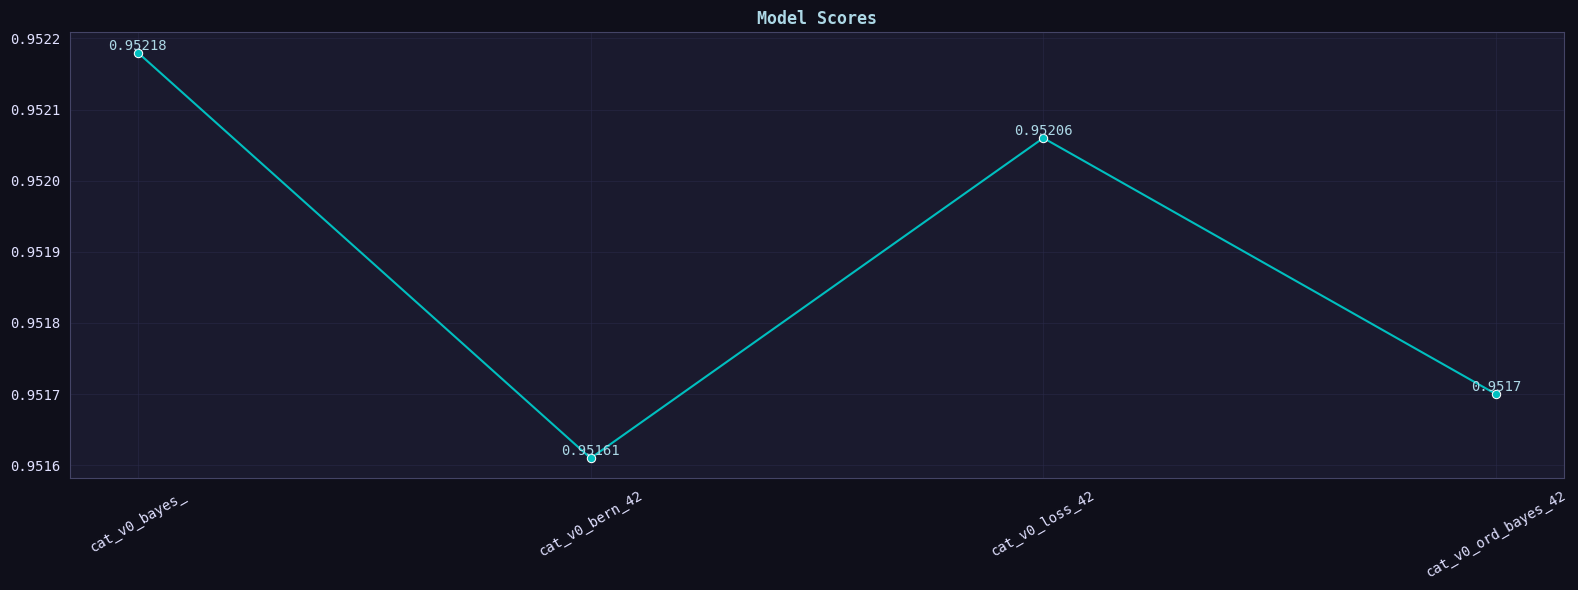

In [42]:
## -- Get Scores --
all_model_scores = {}
all_scores = []

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_model_scores[k] = y
            all_scores.append(float(y))

plt.figure(figsize=(16, 6))
sns.lineplot(all_model_scores, marker='o')
plt.title('Model Scores', fontweight='semibold')
plt.tick_params('x', rotation=30)

for i, s in enumerate(all_model_scores.values()):
    plt.text(float(i), s+4e-6, s, ha='center', va='baseline')

plt.tight_layout()
plt.show()

cat_v0_bayes__95218 saved!


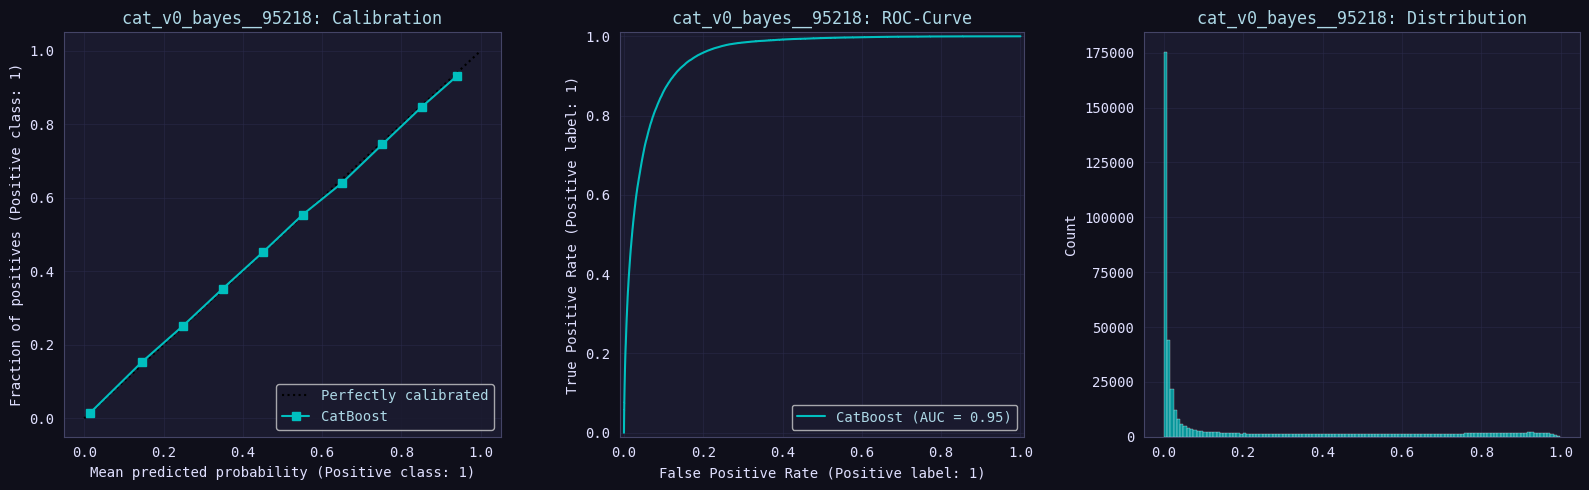


cat_v0_bern_42_95161 saved!


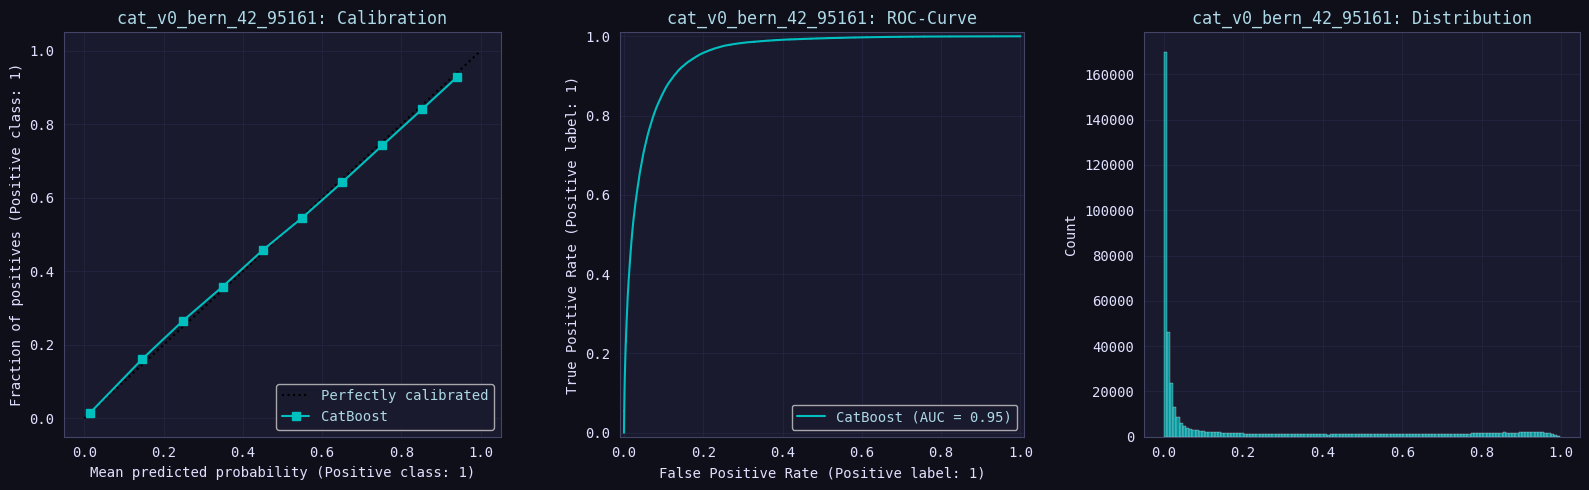


cat_v0_loss_42_95206 saved!


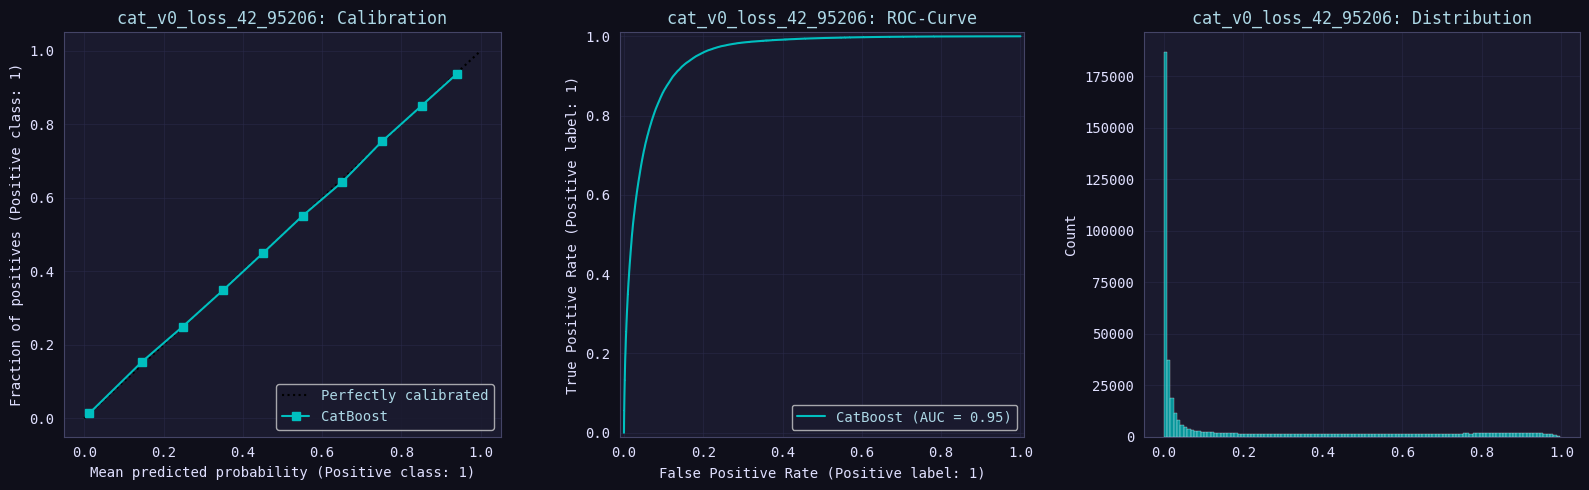


cat_v0_ord_bayes_42_9517 saved!


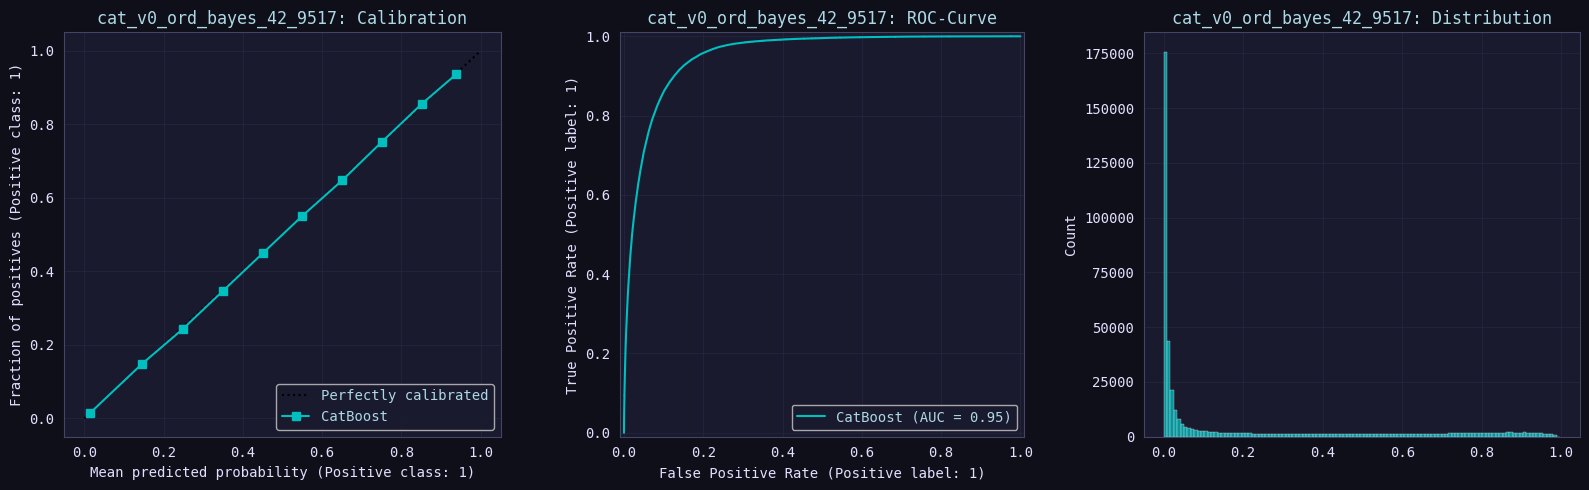

In [43]:
## -- Get oof predictions --
oof_predictions = []

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            ## -- Save oof predictions --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"oof_{n}.npy", y)
            print(f'{n} saved!')

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5)) 
            CalibrationDisplay.from_predictions(train[TARGET], y, n_bins=10, name='CatBoost', ax=axs[0])
            axs[0].set_title(f"{n}: Calibration")

            RocCurveDisplay.from_predictions(train[TARGET], y, name='CatBoost', ax=axs[1])
            axs[1].set_title(f"{n}: ROC-Curve")

            sns.histplot(y, ax=axs[2])
            axs[2].set_title(f"{n}: Distribution")
            
            plt.tight_layout()
            plt.show()

            print()

In [44]:
## -- Save test predictions/submission --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':

            ## -- Base submission file --
            n = f"{k}_{str(all_scores[i]).split('.')[1]}"
            np.save(f"test_{n}.npy", y)

            submit[TARGET] = y
            submit.to_csv(f'submit_{n}.csv', index=False)
            print(f'{n} saved! {y.shape}')

submit.head(10)

cat_v0_bayes__95218 saved! (188165,)
cat_v0_bern_42_95161 saved! (188165,)
cat_v0_loss_42_95206 saved! (188165,)
cat_v0_ord_bayes_42_9517 saved! (188165,)


,id,PitNextLap
0,439140,0.005000
1,439141,0.006950
2,439142,0.003653
3,439143,0.158625
4,439144,0.818116
5,439145,0.330711
6,439146,0.001278
7,439147,0.004888
8,439148,0.013658
9,439149,0.001113


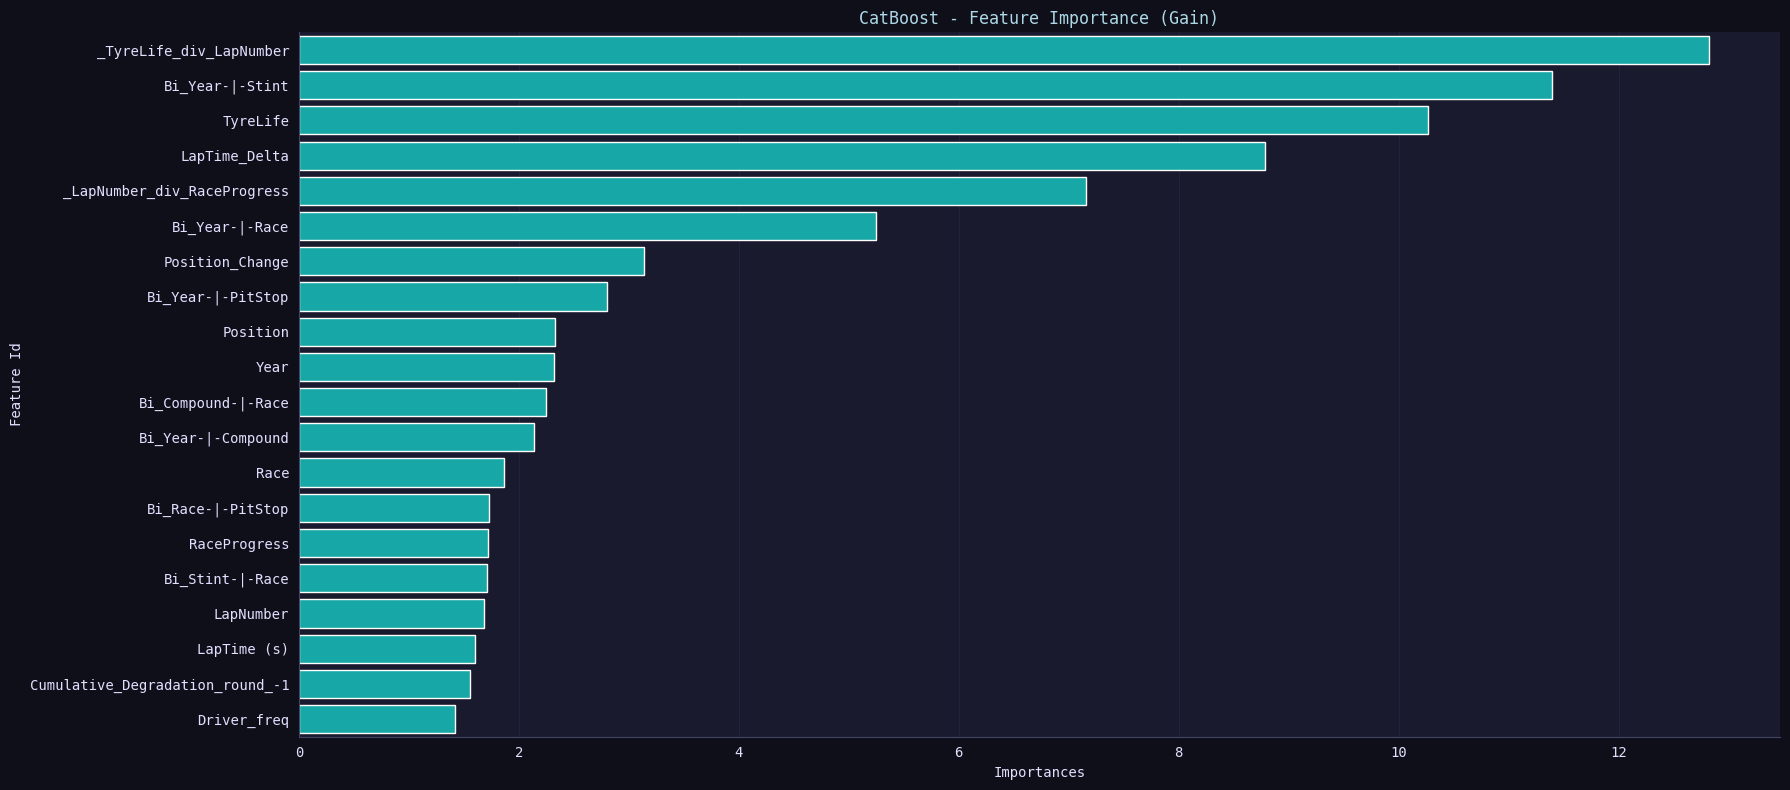

In [45]:
## -- Plot Feature Importances --
MAX = 20
get_model = all_model_predictions[list(all_model_predictions.keys())[-1]]
feature_imp = get_model['model'].get_feature_importance(prettified=True)

plt.figure(figsize=(18, 8))
ax = sns.barplot(x='Importances', y='Feature Id', data=feature_imp.head(MAX))

ax.set_title("CatBoost - Feature Importance (Gain)")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()